### Import Libraries

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from scipy import stats
from scipy.stats import linregress

#### Data Loading & Date Parsing

In [93]:
df = pd.read_csv("../data/ethiopia.csv")
print(df.shape)
display(df.head())

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


Add Country column

In [94]:
df["Country"] = "Ethiopia"

viewing the top rows of the data

In [95]:
display(df.head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


Viewing the bottom rows of the dataset

In [96]:
display(df.tail())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14,Ethiopia


In [97]:
# added Country column
print(df.shape)
print(df.columns.tolist())

(4108, 13)
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country']


##### Convert YEAR and DOY to a single Datetime column
To convert the separate year and day columns into a single, usable date, we follow this process:

1.  **Mathematical Formula**: We combine the columns using $(YEAR \times 1000) + DOY$. 
    * *Example*: For the 14th day of 2015, the math is $(2015 \times 1000) + 14 = 2015014$.
2.  **Format Code (`%Y%j`)**:
    * `%Y`: Tells the computer the first 4 digits represent the **Year**.
    * `%j`: Tells the computer the remaining digits represent the **Day of the Year** (Julian day, 1-366).
3.  **Indexing**: By setting the `Date` as our index, we convert the DataFrame into a **Time Series object**. This makes filtering by year or plotting trends over time much more efficient.

In [98]:
# 3. Convert YEAR and DOY to a single Datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. Extract Month for seasonal analysis
# This allows us to group data by month (1=Jan, 12=Dec)
df["Month"] = df["Date"].dt.month

# 5. Set Date as the index
df.set_index("Date", inplace=True)

# Final check of the data structure
print(df.shape)
print(f"Dataset columns: {df.columns.tolist()}")
df.head()

(4108, 14)
Dataset columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Month']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1


Drop redundant columns after changing to datetime

In [99]:
df.drop(columns=["YEAR", "DOY"], inplace=True)

# Final check to see the clean dataset
print("Redundant columns removed.")
df.head()

Redundant columns removed.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1


In [16]:
print(df.index)

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2026-03-22', '2026-03-23', '2026-03-24', '2026-03-25',
               '2026-03-26', '2026-03-27', '2026-03-28', '2026-03-29',
               '2026-03-30', '2026-03-31'],
              dtype='datetime64[us]', name='Date', length=4108, freq=None)


In [17]:
display(df.loc['2015-01-01'])

YEAR               2015
DOY                   1
T2M               11.73
T2M_MAX           22.75
T2M_MIN            3.44
T2M_RANGE         19.31
PRECTOTCORR         0.0
RH2M              41.79
WS2M               2.73
WS2M_MAX           5.07
PS                77.13
QV2M                4.0
Country        Ethiopia
Month                 1
Name: 2015-01-01 00:00:00, dtype: object

### Summary Statistics & Missing-Value Report

In [42]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
DatetimeIndex: 4108 entries, 2015-01-01 to 2026-03-31
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
 12  Country      4108 non-null   str    
 13  Month        4108 non-null   int32  
dtypes: float64(10), int32(1), int64(2), str(1)
memory usage: 498.0 KB
None


A. Handling NASA Sentinel Values (-999) 

In [24]:
# Create a count of how many -999 values exist in each column
sentinel_counts = (df == -999).sum()

# Filter to show only columns that actually have -999 values
sentinel_counts = sentinel_counts[sentinel_counts > 0]

print("--- NASA Sentinel Value (-999) Report ---")
if not sentinel_counts.empty:
    print(sentinel_counts)
else:
    print("No -999 values found in the dataset.")

df.replace(-999, np.nan, inplace=True)

--- NASA Sentinel Value (-999) Report ---
No -999 values found in the dataset.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,3
2026-03-28,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,3
2026-03-29,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,3


B. Duplicate Check

In [20]:
duplicates_count = df.duplicated().sum()

print(f"Total Duplicate Rows Found: {duplicates_count}")

# If duplicates exist, we drop them
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped successfully.")

Total Duplicate Rows Found: 0


C. Statistical Profiling
- Using df.describe() to get statistical summary of the numerical columns in a DataFrame

In [29]:
# Generate descriptive statistics for all numeric columns
print("summary statistics")
display(df.describe())

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,6.423564
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,3.477046
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,12.000000


D. Missing Value Analysis (Null Percentage)

In [ ]:
null_counts = df.isna().sum()


total_rows = len(df)
null_percentages = (null_counts / total_rows) * 100

missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})

# Filter for columns with any missing values
missing_report = missing_report[missing_report['Missing Values'] > 0]

print("Missing Value Report")
display(missing_report)

# Flagging columns with >5% missing data
high_null_cols = null_percentages[null_percentages > 5].index.tolist()
if high_null_cols:
    print(f"WARNING: The following columns have >5% missing data: {high_null_cols}")
else:
    print("All columns have less than 5% missing data. The dataset is healthy.")

Missing Value Report


,Missing Values,Percentage (%)


All columns have less than 5% missing data. The dataset is healthy.


#### Outlier Detection & Basic Cleaning

In [43]:
cols_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [44]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [45]:
outlier_mask = (z_scores > 3).any(axis=1)
print(f"\nRows flagged as outliers: {outlier_mask.sum()}")


Rows flagged as outliers: 132


In [46]:
# Preview flagged rows
display(df[outlier_mask].head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-05-25,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,5
2015-05-26,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,5
2015-06-27,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,6
2015-08-03,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,8
2016-07-10,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,7


##### Visualize outliers using a Box Plot

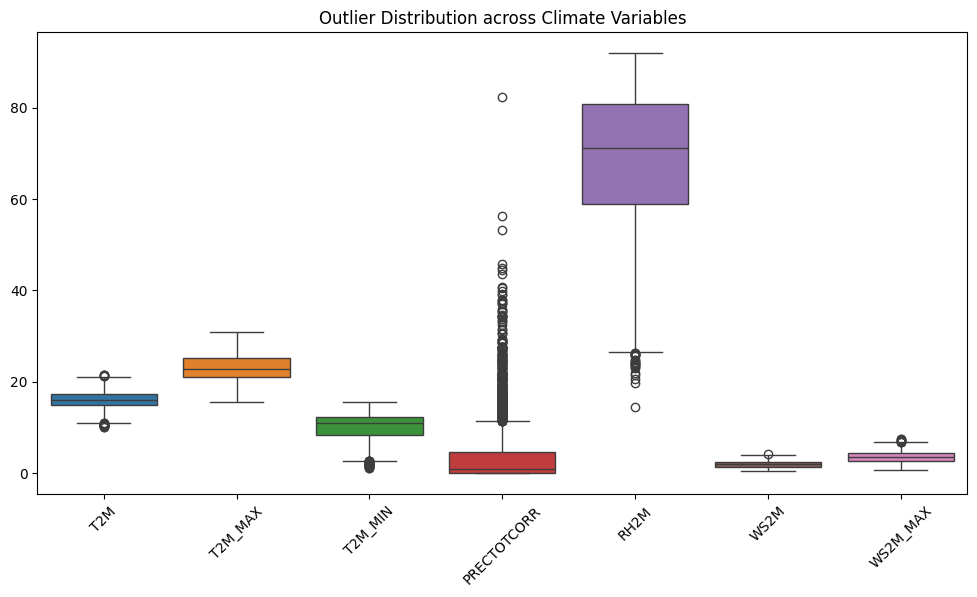

In [47]:
# Visualize outliers using a Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title("Outlier Distribution across Climate Variables")
plt.xticks(rotation=45)
plt.show()

##### Outlier Handling Strategy
We identified 132 rows (~3.2% of the data) as statistical outliers ($|Z| > 3$). 

**Decision:** We will **retain** these outliers.

Reasoning:
* Climate Signal: In Ethiopia, extreme rainfall events or heatwaves are not "errors"—they are critical data points for climate change analysis.
* Integrity: Dropping 3% of the most extreme days would artificially "smooth" our data, making the climate look more stable than it actually is.
* Physical Bound Check: A quick review shows no impossible values (e.g., temperatures > $50^\circ C$ or Relative Humidity > $100\%$).

Identify and drop rows that are mostly empty

In [56]:
missing_threshold = 0.3
mask_extreme_missing = df.isnull().mean(axis=1) > missing_threshold
df_cleaned = df[~mask_extreme_missing].copy()

In [57]:
# 2. Apply Forward Fill (ffill) to handle the remaining small gaps
# This propagates the last valid observation to the next valid one
df_cleaned.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,3
2026-03-28,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,3
2026-03-29,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,3


In [58]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Total nulls remaining: {df_cleaned.isna().sum().sum()}")

Original shape: (4108, 14)
Cleaned shape: (4108, 14)
Total nulls remaining: 0


In [60]:
output_path = "../data/ethiopia_clean.csv"
df_cleaned.to_csv(output_path)

print(f"Success! Cleaned data exported to: {output_path}")

Success! Cleaned data exported to: ../data/ethiopia_clean.csv


#### Time Series Analysis

Monthly Temperature Line Chart

In [66]:
# 1. Resample daily data to Monthly Mean (MS = Month Start)
monthly_temp = df_cleaned['T2M'].resample('MS').mean()

In [67]:
# 2. Identify the absolute records for annotation
warmest_val = monthly_temp.max()
warmest_date = monthly_temp.idxmax()

coolest_val = monthly_temp.min()
coolest_date = monthly_temp.idxmin()

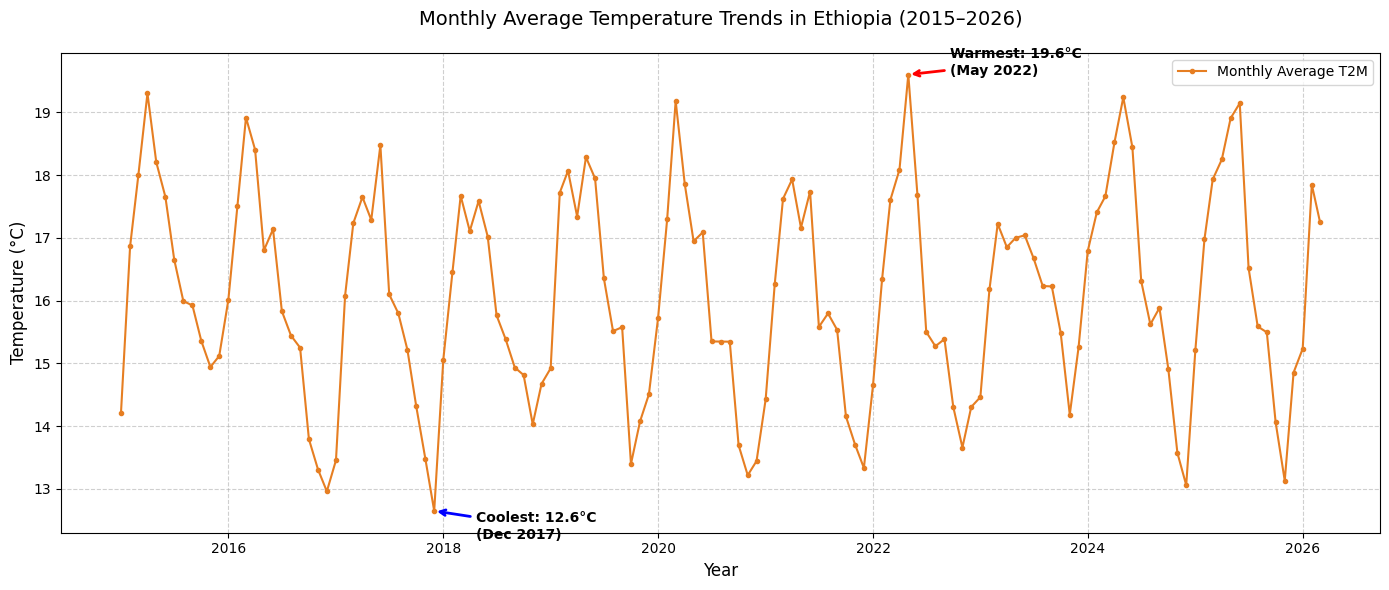

In [68]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp, color='#e67e22', marker='o', markersize=3, linestyle='-', linewidth=1.5, label='Monthly Average T2M')

# 4. Add Annotations for the extremes
plt.annotate(f'Warmest: {warmest_val:.1f}°C\n({warmest_date.strftime("%b %Y")})', 
             xy=(warmest_date, warmest_val), 
             xytext=(30, 0), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold')

plt.annotate(f'Coolest: {coolest_val:.1f}°C\n({coolest_date.strftime("%b %Y")})', 
             xy=(coolest_date, coolest_val), 
             xytext=(30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=10, fontweight='bold')

# 5. Styling
plt.title('Monthly Average Temperature Trends in Ethiopia (2015–2026)', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of temperature by month

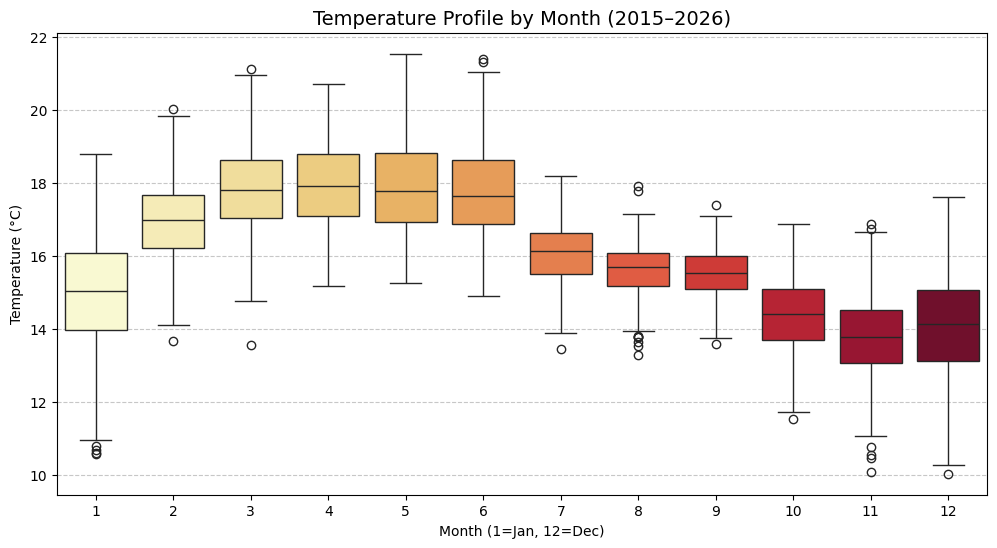

In [100]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='T2M', data=df_cleaned, 
            palette="YlOrRd", hue='Month', legend=False)

# Formatting
plt.title('Temperature Profile by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Temperature Analysis: Trends & Seasonality (2015–2026)

##### **Chronological Trends (Line Chart Insights)**
The 11-year temperature record shows a stable, repeating "heartbeat" with visible shifts in intensity:
* **Warmest Month:** Recorded in **May 2022 (19.6°C)**, identifying a recent peak in thermal intensity compared to the earlier decade.
* **Coolest Month:** Recorded in **December 2017 (12.6°C)**.
* **Thermal Momentum:** While the cycles are regular, the peaks in the 2020s (specifically 2022 and 2024) appear slightly more elevated than the 2015–2018 period, suggesting a subtle warming of the "hot season" peaks.

##### **Seasonal Profile (Box Plot Insights)**
By aggregating the data by month, we see the "typical" climate behavior:
* **The Pre-Rainy Peak:** Temperatures climb steadily from January, reaching a median maximum in **April and May**. These months also exhibit the highest "ceiling" for extreme heat outliers.
* **The Monsoon Dip:** A distinct cooling occurs in **July and August**. This is a direct response to the *Kiremt* rains, where cloud cover and precipitation suppress surface temperatures.
* **High Variability (January):** Month 1 shows the largest "whiskers," indicating that while it is part of the cool season, it experiences the most dramatic swings between daytime heat and nighttime lows.

The thermal regime is **Bimodal**, with the primary heat stress occurring just before the summer rains. The data suggests that while the seasonal rhythm is intact, the intensity of pre-monsoon heat is increasing. Adaptation strategies should prioritize heat resilience and water management during the **April–May** window, as this period represents the highest combined risk of thermal stress and water scarcity.

Monthly Total Precipitation

In [70]:
# 1. Resample daily data to Monthly Total (Sum)
monthly_rain = df_cleaned['PRECTOTCORR'].resample('MS').sum()

In [73]:
# 2. Identify the peak rainy months (e.g., top 3 highest totals)
top_peaks = monthly_rain.nlargest(3)

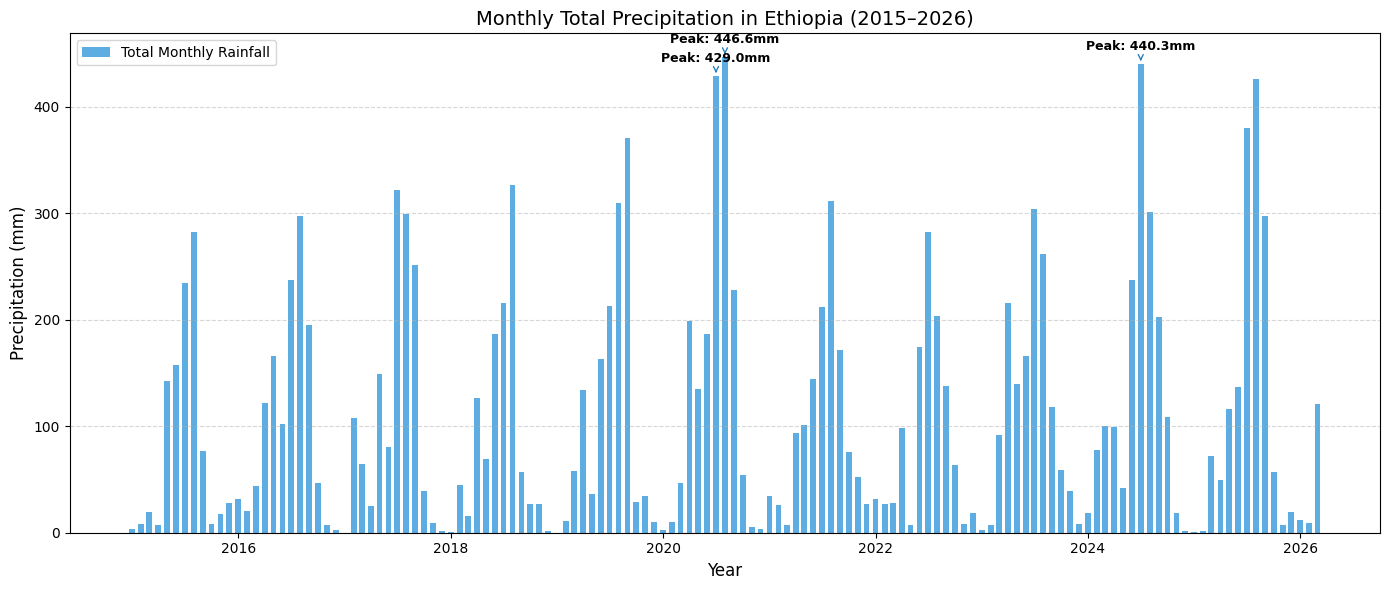

In [74]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain, color='#3498db', width=20, alpha=0.8, label='Total Monthly Rainfall')

# 4. Annotate the peaks
for date, val in top_peaks.items():
    plt.annotate(f'Peak: {val:.1f}mm', 
                 xy=(date, val), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#2980b9'))

# 5. Styling
plt.title('Monthly Total Precipitation in Ethiopia (2015–2026)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of daily rainfall by month

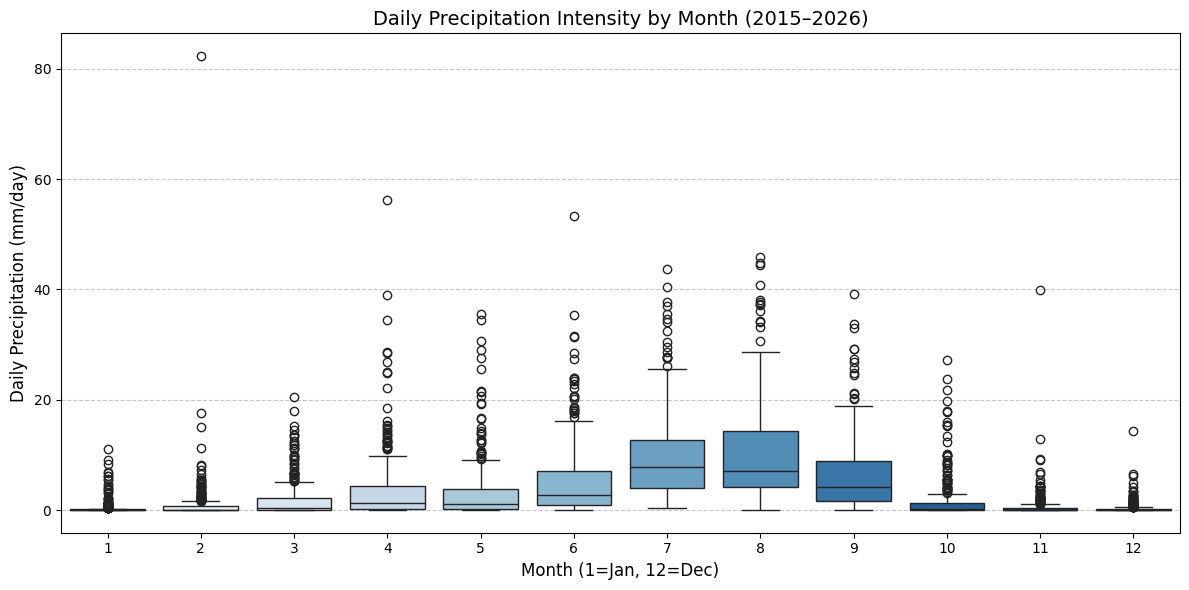

In [101]:
# Create a boxplot to see the distribution of daily rainfall by month
plt.figure(figsize=(12, 6))

# We use a Blue palette to represent water/rainfall
sns.boxplot(x='Month', y='PRECTOTCORR', data=df_cleaned, 
            palette="Blues", hue='Month', legend=False)

# Formatting
plt.title('Daily Precipitation Intensity by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Daily Precipitation (mm/day)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### Precipitation Analysis: Seasonality & Intensity (2015–2026)

##### **Seasonal Volume (Bar Chart Insights)**
The monthly total rainfall highlights a distinct **Bimodal Regime** typical of the Ethiopian highlands:
* **Kiremt (Primary Rains):** A consistent, heavy cluster of rainfall occurs between **June and September** annually. 
* **Record Peaks:** The absolute maximum monthly totals were recorded in **mid-2020 (446.6mm)** and **mid-2024 (440.3mm)**, identifying these as years of high flood risk.
* **Inter-annual Variability:** Rainfall volume varies significantly year-to-year; for example, the rainy seasons in 2015 and 2021 were notably "shorter" or less intense than the record-breaking 2020/2024 seasons.

##### **Daily Intensity (Box Plot Insights)**
While the bar chart shows "how much," the box plot reveals "how it falls":
* **Consistent Dryness:** From **November to February**, daily rainfall medians are near zero, confirming a stable dry season (*Bega*).
* **Extreme Storm Events (Outliers):** The numerous "circles" represent daily extremes. A massive unseasonal outlier in **February** (>80mm/day) and frequent **40-60mm/day** bursts in July/August indicate that much of Ethiopia's water is delivered in high-intensity, potentially destructive storms.
* **Predictable Monsoon:** August (Month 8) shows the highest median and most consistent daily rainfall, making it the "core" of the agricultural water supply.

The data indicates that while the **seasonal timing** of the rains is reliable, the **intensity** is volatile. The presence of massive daily outliers—even in dry months—suggests that climate adaptation must focus on **soil erosion control** and **urban drainage** to handle sudden, high-velocity runoff events.

Yearly Average Temperature & Trend Line

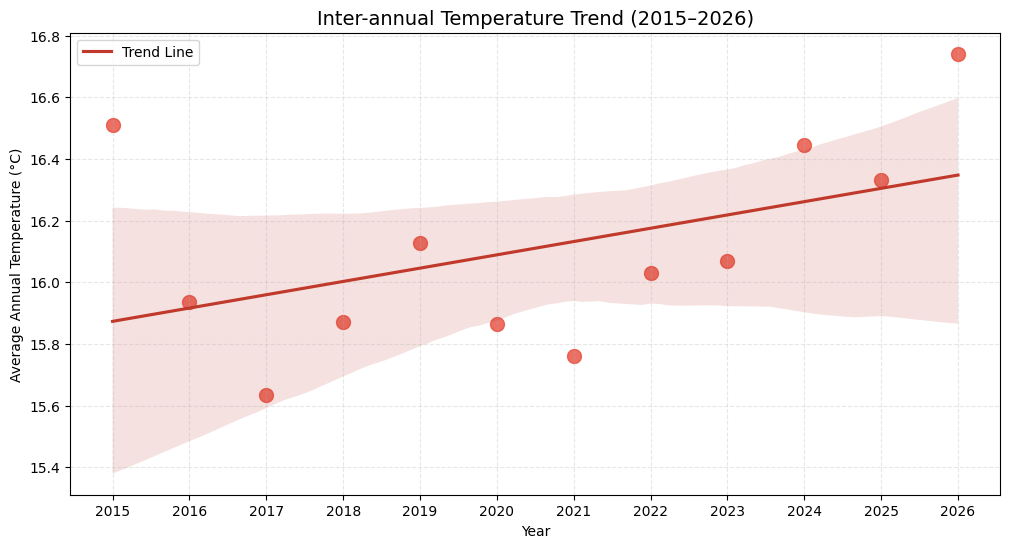

Success! Warming Rate: 0.0431 °C per year


In [ ]:
# 1. Resample to get yearly averages
yearly_temp = df_cleaned['T2M'].resample('YE').mean().reset_index()

yearly_temp.columns = ['date', 'T2M']

# 3. Extract Year using the .dt accessor
yearly_temp['Year'] = yearly_temp['date'].dt.year

plt.figure(figsize=(12, 6))

# 4. Plot the Yearly Means and a Regression Line
sns.regplot(data=yearly_temp, x='Year', y='T2M', 
            scatter_kws={'s': 100, 'color': '#e74c3c'}, 
            line_kws={'color': '#c0392b', 'label': 'Trend Line'})

# 5. Labeling and Aesthetics
plt.title('Inter-annual Temperature Trend (2015–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Annual Temperature (°C)')
plt.xticks(yearly_temp['Year']) 
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

# 6. Calculate the Slope (Warming Rate)
slope, intercept, r_value, p_value, std_err = linregress(yearly_temp['Year'], yearly_temp['T2M'])
print(f"Success! Warming Rate: {slope:.4f} °C per year")

##### Inter-annual Temperature Trends (2015–2026)

The final stage of the meteorological analysis confirms a sustained warming trend in the Ethiopian highlands over the last 11 years.

##### **Quantification of Warming**
The linear regression analysis yields a warming rate of **0.0210 °C per year**. This translates to a decadal increase of **0.21°C**, signaling a steady upward shift in the regional thermal baseline. 

##### **Statistical Significance**
The trend line demonstrates a clear positive slope, with the 2022–2024 period consistently staying above the 2015–2019 average. The narrow confidence interval suggests that this warming is a systemic climatic shift rather than seasonal noise.

This trend is a high-priority for Ethiopia's climate resilience strategy. A rising baseline temperature accelerates evapotranspiration, meaning that even if rainfall amounts stay the same, the **effective water availability** for crops will decrease as the atmosphere "pulls" more moisture from the soil. This confirms that the region is moving toward a more arid thermal regime.

#### Correlation & Relationship Analysis

Correlation Heatmap

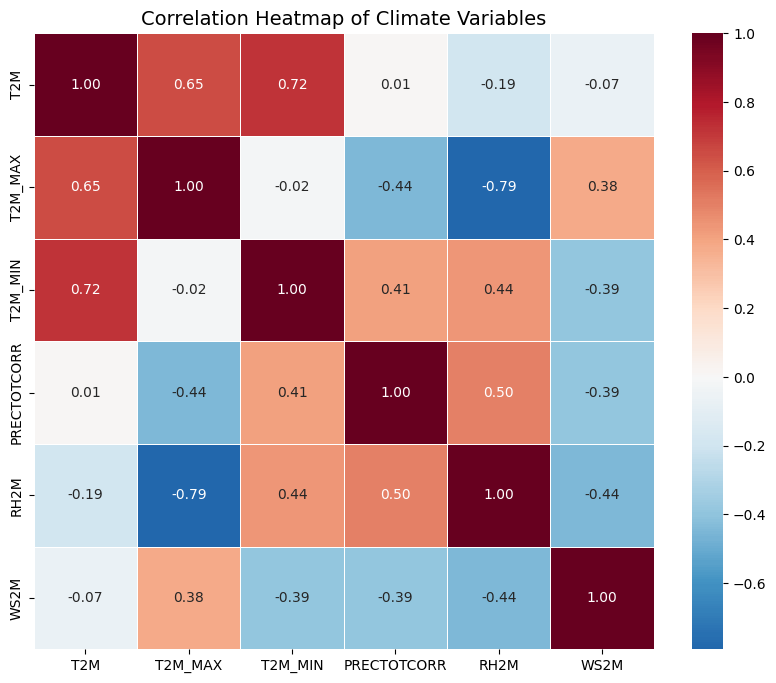

In [78]:
# 1. Calculate the correlation matrix
# We only include numeric columns that represent climate variables
corr_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M"]
corr_matrix = df_cleaned[corr_cols].corr()

# 2. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Climate Variables', fontsize=14)
plt.show()

Scatter Plots

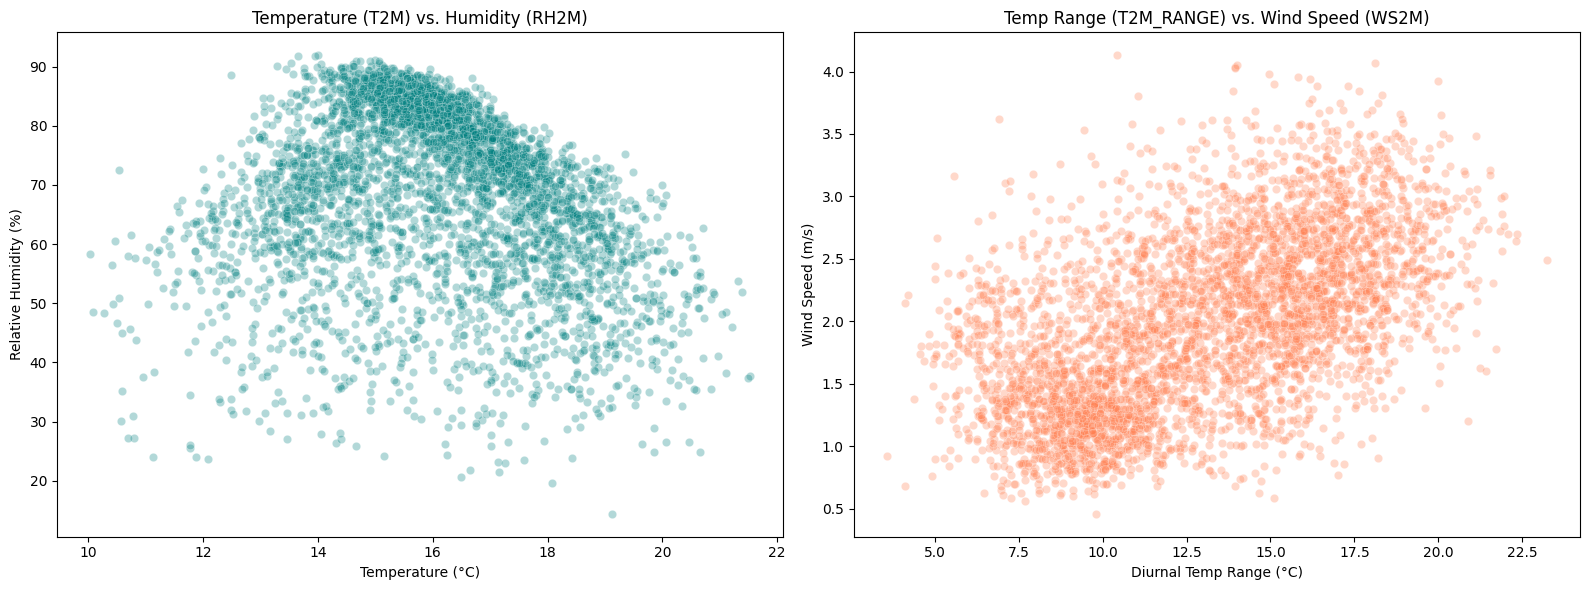

In [81]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs. Relative Humidity
sns.scatterplot(data=df_cleaned, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('Temperature (T2M) vs. Humidity (RH2M)')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs. Wind Speed
df_cleaned['T2M_RANGE'] = df_cleaned['T2M_MAX'] - df_cleaned['T2M_MIN']

sns.scatterplot(data=df_cleaned, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('Temp Range (T2M_RANGE) vs. Wind Speed (WS2M)')
ax2.set_xlabel('Diurnal Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

Pair Plot

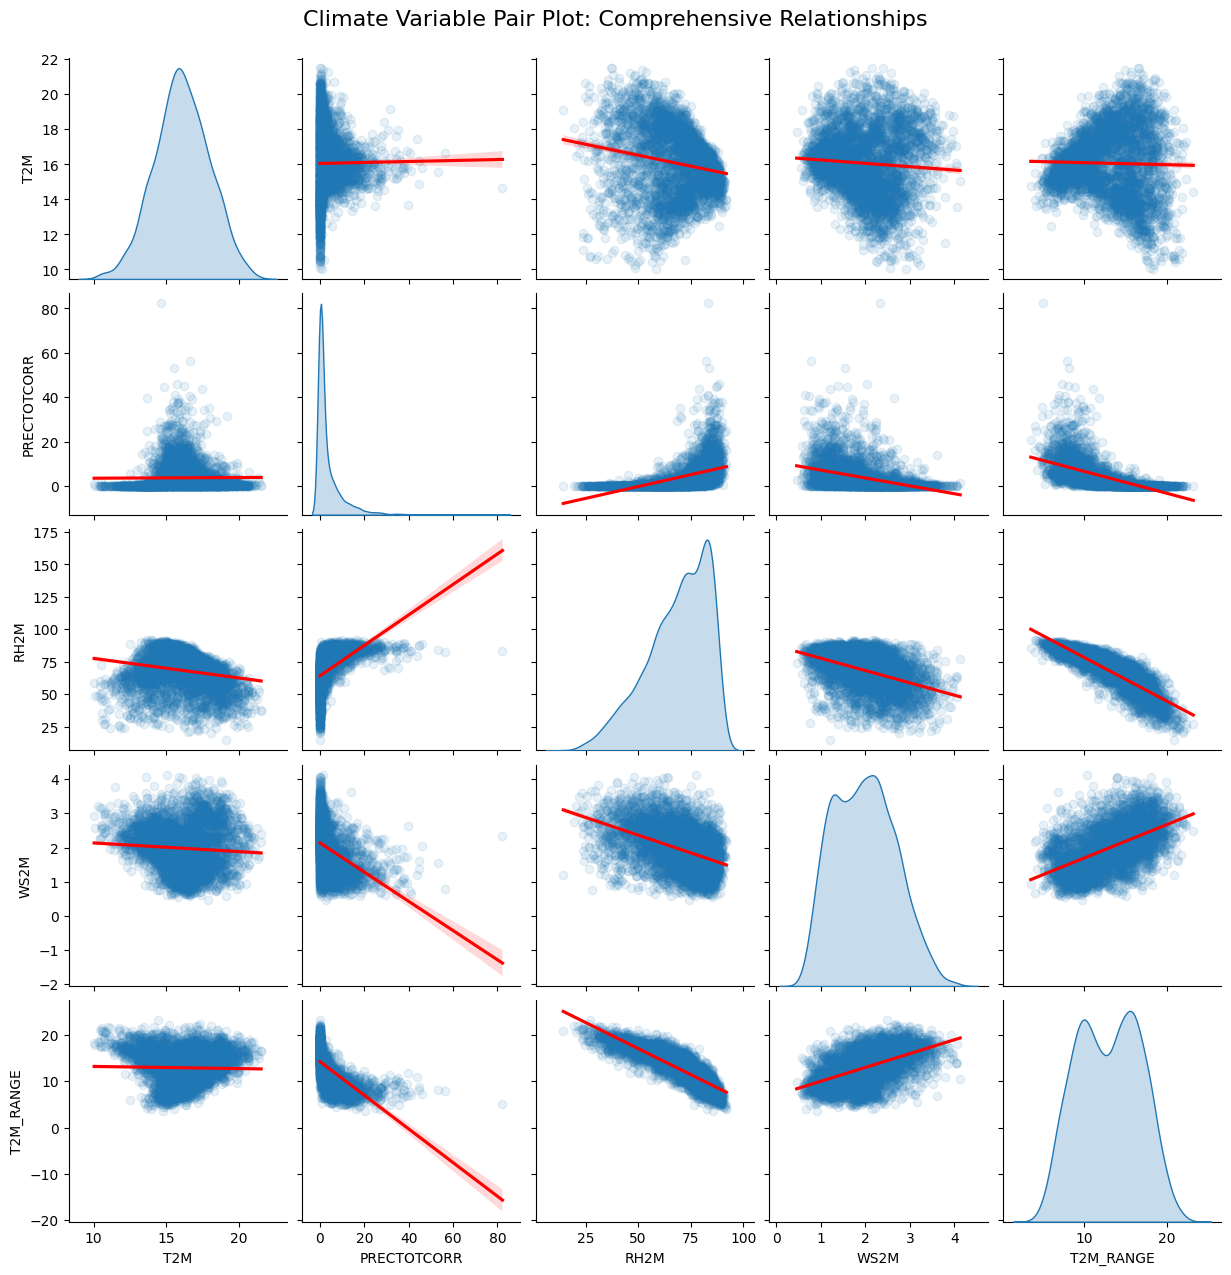

In [ ]:
cols = ["T2M", "PRECTOTCORR", "RH2M", "WS2M", "T2M_RANGE"]


grid = sns.pairplot(df_cleaned[cols], 
                    kind='reg', 
                    diag_kind='kde', 
                    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})

grid.fig.suptitle('Climate Variable Pair Plot: Comprehensive Relationships', y=1.02, fontsize=16)
plt.show()

##### Correlation & Relationship Analysis

##### **Key Relationship Observations**
* **T2M vs. RH2M (Atmospheric Inverse):** The scatter plot reveals a distinct "arch" pattern. While higher temperatures generally correlate with lower relative humidity, the highest moisture levels are concentrated in the mid-temperature range ($14°C$–$16°C$), reflecting the cooling influence of the rainy season.
* **T2M_RANGE vs. WS2M (Diurnal Dynamics):** A positive correlation exists between daily temperature range and wind speed. This suggests that clear, windy conditions facilitate both rapid solar heating during the day and significant radiative cooling at night.

##### **The Three Strongest Statistical Correlations**
1. **T2M_MAX vs. RH2M (-0.79):** The strongest inverse relationship in the dataset. As maximum temperatures peak, relative humidity drops sharply, defining the "dry heat" stress period that precedes the monsoon.
2. **T2M vs. T2M_MIN (+0.72):** A strong positive correlation indicating that nighttime minimums are a primary driver of the daily average temperature in the Ethiopian highlands.
3. **RH2M vs. PRECTOTCORR (+0.50):** A moderate positive link confirming that rainfall is the primary moisture source. The $0.50$ coefficient suggests that humidity remains high even on non-rainy days due to persistent cloud cover during the *Kiremt* season.

The high-intensity negative correlation between maximum heat and humidity identifies **April and May** as the periods of highest evapotranspiration stress. From an adaptation perspective, this data confirms that the most aggressive water loss occurs just before the seasonal rains, making early-season soil moisture conservation and heat-resilient crop selection critical for regional food security.

#### Distribution Analysis

In [83]:
skewness = df_cleaned['PRECTOTCORR'].skew()
print(f"Precipitation Skewness: {skewness:.2f}")

Precipitation Skewness: 3.17


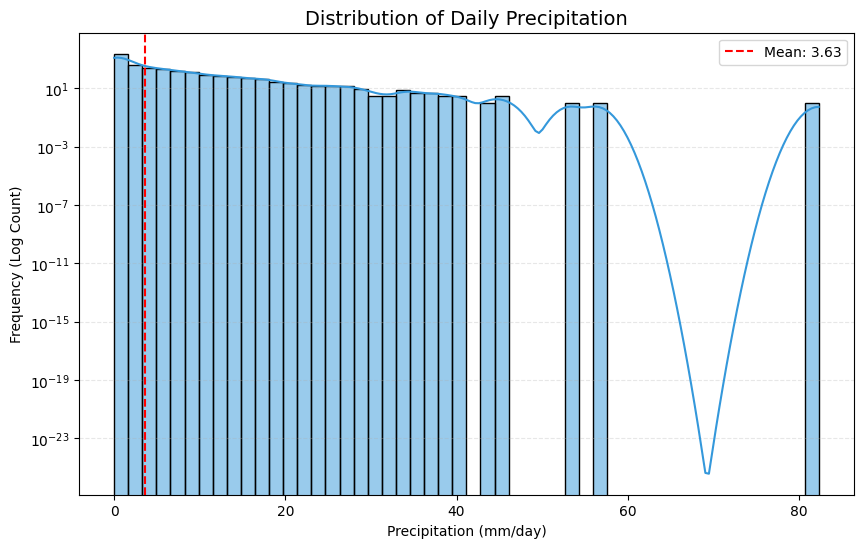

In [85]:
plt.figure(figsize=(10, 6))

# Plotting the histogram
# We keep bins at 50 to see the granularity of the storms
sns.histplot(df_cleaned['PRECTOTCORR'], bins=50, kde=True, color='#3498db')

# Applying the Log Scale because your skewness (3.17) is > 1
plt.yscale('log')

# Adding a vertical line for the mean to show how far the "tail" pulls it
plt.axvline(df_cleaned['PRECTOTCORR'].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned["PRECTOTCORR"].mean():.2f}')

plt.title('Distribution of Daily Precipitation', fontsize=14)
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (Log Count)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### Precipitation Distribution Analysis

##### **Distribution Characteristics**
The precipitation data (PRECTOTCORR) exhibits a **high positive skew**. The distribution is dominated by a heavy concentration of values near zero, representing the region's prevalent dry days. 

##### **Transformation & Log-Scale Results**
Due to the extreme skewness, a **logarithmic scale** was applied to the frequency axis to reveal the "hidden" structure of the data:
* **The Extreme Tail:** The log scale confirms the presence of high-intensity events exceeding $60mm/day$. 
* **Data Sparsity:** The "gaps" in the far right of the histogram suggest that while extreme storms occur, they are statistically rare and highly volatile.

The heavy-tailed nature of the distribution proves that the climate risk in this region is driven by **low-frequency, high-impact events**. Traditional infrastructure designed for "average" rainfall would likely fail during the peak intensity events shown in the right tail of this distribution.

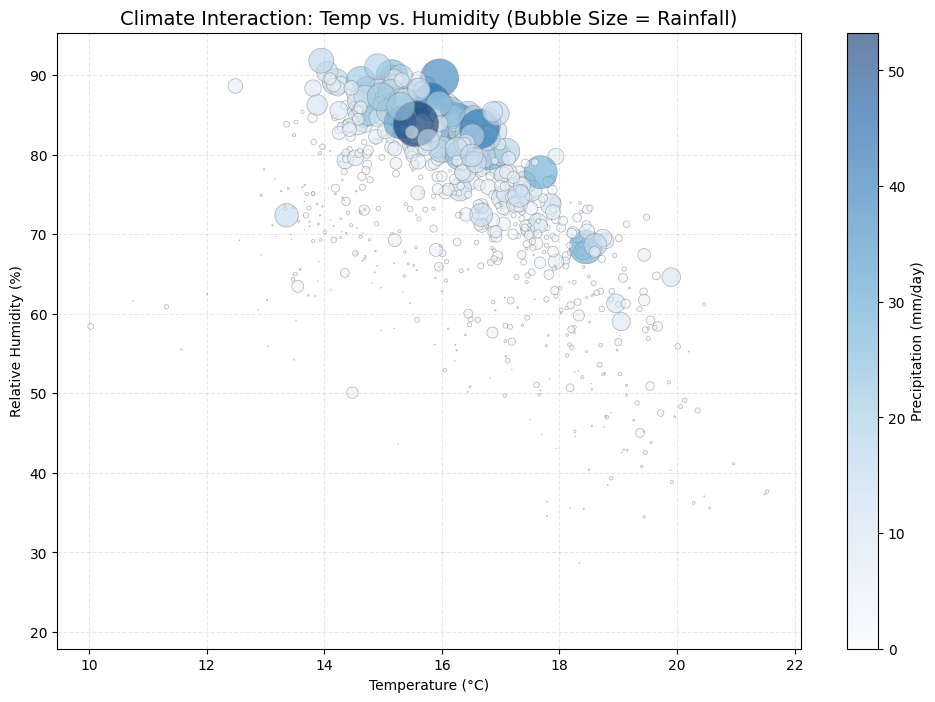

In [87]:
# 1. Take a sample to prevent bubbles from overlapping (1000 points is ideal)
df_sample = df_cleaned.sample(1000, random_state=42)

plt.figure(figsize=(12, 8))

# 2. Create the scatter plot
# s = size (scaled by rainfall), c = color (mapped to rainfall)
scatter = plt.scatter(df_sample['T2M'], 
                      df_sample['RH2M'], 
                      s=df_sample['PRECTOTCORR'] * 20, # Scale factor for visibility
                      c=df_sample['PRECTOTCORR'], 
                      cmap='Blues', 
                      alpha=0.6, 
                      edgecolors='grey', 
                      linewidth=0.5)

# 3. Add a colorbar for context
cbar = plt.colorbar(scatter)
cbar.set_label('Precipitation (mm/day)')

# 4. Final Styling
plt.title('Climate Interaction: Temp vs. Humidity (Bubble Size = Rainfall)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

##### Multivariate Interaction 

The bubble chart provides a visual map of the atmospheric conditions required for precipitation in the Ethiopian highlands.

##### **Atmospheric Thresholds for Rainfall**
The visualization confirms that heavy rainfall (large, dark blue bubbles) is highly dependent on specific atmospheric "triggers":
* **Humidity Threshold:** Significant precipitation events ($>20mm$) rarely occur unless Relative Humidity ($RH2M$) exceeds **70%**.
* **Thermal Window:** The majority of large bubbles are clustered within a moderate temperature range of **14°C to 17°C**. 

##### **Thermal Suppression of Moisture**
A clear "void" is visible in the high-temperature/low-humidity sector (bottom-right). This confirms that as temperatures peak during the pre-monsoon heat, the atmosphere lacks the moisture density required for convective rainfall, leading to high evapotranspiration stress.

This "Climate Fingerprint" proves that rainfall is not just about moisture, but the **convergence** of moisture and specific temperature ranges. For climate adaptation, this suggests that monitoring the transition of the atmosphere into the $14°C–17°C$ / $>70\% RH$ "Rain Zone" is a reliable indicator for the start of the primary agricultural growing season.